In [1]:
%load_ext autoreload
%autoreload 2

## Imports and model download

In [2]:
import os 
import sys

sys.path.append('../src')

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
from huggingface_hub import snapshot_download, notebook_login

## our custom lib
from rescue import naip, utils, models

os.makedirs('../generated', exist_ok = True)

# if needed
os.environ['CUDA_VISIBLE_DEVICES']="2"

In [3]:
### to download sam3 ###
notebook_login()


In [4]:
### Download sam3 model from huggingface ###
model_path = "../generated/sam3"
snapshot_download(repo_id="facebook/sam3", local_dir=model_path)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

'/edrive3/srohatgi/RESCUE/generated/sam3'

## Download Satellite Image

### area we're downloading data for

In [5]:
# geojson_path = '../data/sample_geojsons/sample_2.geojson'
geojson_path = '../data/disaster_city.geojson'

gpd.read_file(geojson_path).explore()

### Download NAIP imagery


In [6]:
img_xr = naip.download_naip_for_geojson(
geojson_path = geojson_path,
time_range = "2018-01-01/2027-01-01", 
)

img_xr

<xarray.DataArray (band: 4, y: 1057, x: 1273)> Size: 5MB
array([[[255,  68,  68, ...,  99,  88,  68],
        [255,  75,  66, ...,  92,  80,  66],
        [255,  74,  68, ...,  80,  71,  62],
        ...,
        [126, 129, 134, ..., 184, 181, 181],
        [129, 131, 129, ..., 185, 181, 181],
        [131, 130, 129, ..., 185, 181, 255]],

       [[255,  87,  80, ..., 127, 114,  84],
        [255,  90,  80, ..., 121, 104,  81],
        [255,  92,  82, ..., 101,  93,  71],
        ...,
        [115, 117, 119, ..., 168, 164, 164],
        [116, 119, 119, ..., 169, 164, 164],
        [119, 121, 122, ..., 168, 164, 255]],

       [[255,  77,  76, ...,  89,  85,  77],
        [255,  79,  75, ...,  86,  84,  76],
        [255,  79,  75, ...,  81,  78,  74],
        ...,
        [104, 104, 102, ..., 152, 152, 152],
        [103, 106, 106, ..., 155, 151, 151],
        [105, 107, 106, ..., 153, 150, 255]],

       [[255, 158, 148, ..., 189, 176, 143],
        [255, 162, 150, ..., 185, 167, 142],
        [255, 164, 154, ..., 166, 140, 123],
        ...,
        [116, 116, 116, ..., 127, 123, 123],
        [117, 118, 118, ..., 126, 125, 125],
        [119, 119, 122, ..., 123, 126, 255]]],
      shape=(4, 1057, 1273), dtype=uint8)
Coordinates:
  * x            (x) float64 10kB -96.35 -96.35 -96.35 ... -96.35 -96.35 -96.35
  * y            (y) float64 8kB 30.58 30.58 30.58 30.58 ... 30.57 30.57 30.57
  * band         (band) int64 32B 1 2 3 4
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_DOCUMENTNAME:      Wellborn NW 3009630
    TIFFTAG_IMAGEDESCRIPTION:  Image courtesy of USDA Farm Service Agency's N...
    TIFFTAG_DATETIME:          2022:10:25 10:42:51
    TIFFTAG_ARTIST:            Surdex Corporation, 636-368-4400, www.surdex.com
    TIFFTAG_HOSTCOMPUTER:      AMDNODE8
    AREA_OR_POINT:             Area
    scale_factor:              1.0
    add_offset:                0.0
    _FillValue:                255

Text(0.5, 1.0, 'downloaded satellite image')

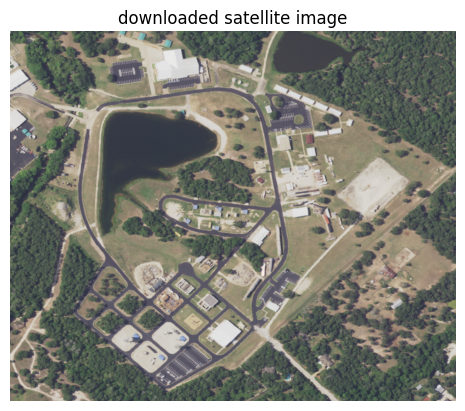

In [7]:
img_rgb = np.moveaxis(img_xr.values[:3], 0, -1)

plt.imshow(img_rgb)
plt.axis('off')
plt.title('downloaded satellite image')

## Use SAM3 to get traversability maps

In [12]:
sam3_pred = models.sam3_predictor('../generated/sam3', device = 'cuda:2')

robot2keywords = {
'spot': ['road', 'pavement', 'sidewalk', 'concrete', 'asphalt', 'building', 'grass', 'dirt', 'barren', 'concrete'],
'small drone': ['building', 'canopy', 'trees', 'forest', 'roof', 'balcony', 'overhang', 'awning'],
'large drone': ['water', 'pond', 'lake', 'river']
}

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

In [15]:
robot2traverse = {}

for robot, keywords in robot2keywords.items():
    results = sam3_pred.pred_on_prompts_and_single_img(img_rgb, keywords, threshold=0.3, mask_threshold=0.5)
    masks, bboxes, scores, labels = utils.collate_sam3_results(results, keywords)

    robot2traverse[robot] = masks.max(axis = 0)
    # plotted = utils.plot_sam3_detections(img_rgb, masks, bboxes, scores, labels)
    # plt.figure(figsize = (10, 10))
    # plt.imshow(plotted)


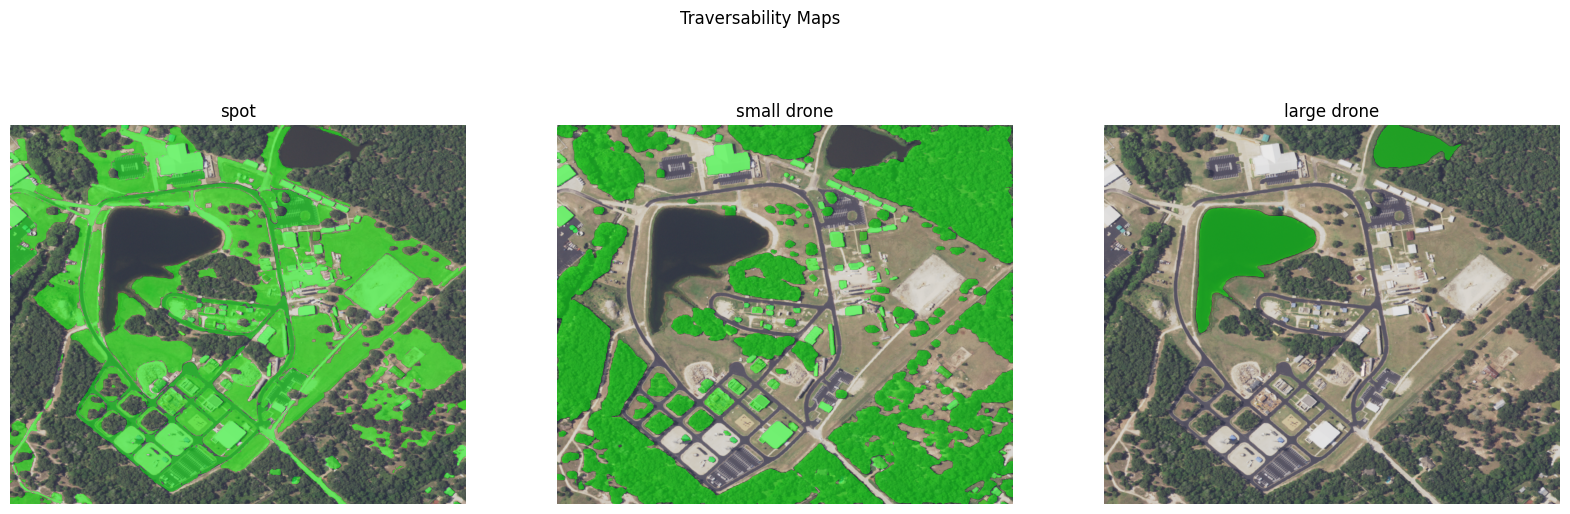

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=len(robot2traverse), figsize = (20, 10))
green_cmap = ListedColormap(['lime'])

for i, (robot, mask) in enumerate(robot2traverse.items()):
    axes[i].imshow(img_rgb)

    transparent_mask = np.ma.masked_where(mask == 0, mask)
    axes[i].imshow(transparent_mask, cmap=green_cmap, alpha=0.5)

    axes[i].set_title(robot)
    axes[i].axis('off')

plt.suptitle("Traversability Maps", y = 0.8);